# EDA

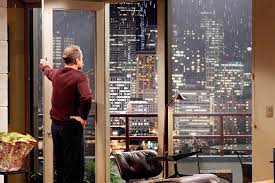

## Project Overview

This notebook explores the **King County Housing Dataset** (home sales in King County, WA,
including Seattle) to answer three concrete questions for a real client, using exploratory
data analysis and light statistical testing.

**Client:** Charles Christensen — *Seller / Investor*
He wants to reinvest for strong returns, and has three open questions:
1. Is there a better **time** to buy or sell?
2. Is **renovating** a property before resale worth the money?
3. Does **location** (specifically, distance to Seattle) drive higher returns?

## Hypotheses to Test

| # | Hypothesis | Tested in |
|---|------------|-----------|
| **H1** | House prices fluctuate depending on season — lower in winter, higher in summer. | Section 2 |
| **H2** | Homes located closer to Seattle allow for a higher return on investment. | Section 4 |
| **H3** | For homes renovated in the last 20 years, the price increase from renovation is largest for homes built before 1950. | Section 3 |


## 0. Setup

Standard imports, plotting defaults, and a small helper function to compute flat-earth
distance (in km) between two lat/long coordinates — used later to compute each home's
distance to downtown Seattle.


In [1]:
import warnings
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import pandas as pd
import missingno as msno
import seaborn as sns
import numpy as np
import math

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {"figure.figsize": (8, 5), "axes.facecolor": "white", "axes.edgecolor": "black"}
)
plt.rcParams["figure.facecolor"] = "w"
pd.plotting.register_matplotlib_converters()
pd.set_option("display.float_format", lambda x: "%.3f" % x)

def flat_distance_km(lat1, lon1, lat2, lon2):
    # Mean latitude in radians for longitude correction
    avg_lat_rad = math.radians((lat1 + lat2) / 2.0)
    
    # Differences scaled to kilometers (1 deg ≈ 111 km)
    dy = (lat2 - lat1) * 111.0
    dx = (lon2 - lon1) * 111.0 * math.cos(avg_lat_rad)
    
    # Standard Euclidean distance formula
    return round(math.sqrt(dx * dx + dy * dy),3)



## 1. Data Loading, Cleaning & Feature Engineering

We load the raw sales data and engineer the features each hypothesis needs:
- a **season** tag and **distance-to-Seattle** for every sale,
- a **geographic grid cluster** ID for spatial (rather than purely linear) location analysis, and
- a **repeat-sales ("resale") dataset**, pairing each property's earlier purchase with its
  later sale so we can measure a *true*, like-for-like return on investment.


In [2]:
# ------ Loading & Cleaning Data -------
df = pd.read_csv("data/eda.csv")

# Fixing yr_renovated format (source data stores it oddly scaled by 10)
df['yr_renovated'] = (df['yr_renovated'] / 10).astype('Int64')

# Changing date to datetime
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')

In [3]:
# ------ Feature Engineering: Seasons --------
# Adding seasons 
season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
}
season_palette = {'Spring': '#4caf50','Summer': '#ffb74d','Fall': '#e57373',  'Winter': '#64b5f6',}
df['season'] = df['date'].dt.month.map(season_map)

In [4]:
# ---- Creating a distance and grid frame -----
seattle_loc = (47.6062,-122.3321) # lat and long for seattle
df['distance'] = df.apply(lambda x: flat_distance_km(seattle_loc[0],seattle_loc[1],x['lat'],x['long']),axis=1)

# adding lat and long bins 
# Define the number of grid bins along each axis
N_BINS_LAT = 6
N_BINS_LONG = 6
# 1. Create equally spaced numeric bins
df['lat_bin'] = pd.cut(df['lat'], bins=N_BINS_LAT)
df['long_bin'] = pd.cut(df['long'], bins=N_BINS_LONG)
# 2. Combine them into a single unique grid cell ID (e.g., "Cell_0_2")
df['grid_cluster'] = (
    'Cell_' + df['lat_bin'].astype(str) + '_' + df['long_bin'].astype(str)
)

In [5]:
# ----- Creating dataset of houses with at least to sales ---
df_sorted = df.sort_values(by=['id', 'date']).copy()

#Shift price and date within each ID group to pull previous transaction data
df_sorted['buy_price'] = df_sorted.groupby('id')['price'].shift(1)
df_sorted['day_bought'] = df_sorted.groupby('id')['date'].shift(1)

#Rename current transaction columns for clarity
df_sorted = df_sorted.rename(columns={'price': 'sell_price', 'date': 'day_sold'})

#Keep only rows that have a previous purchase (removes the initial buy event)
df_resales = df_sorted.dropna(subset=['buy_price']).copy()

#Select and reorder target columns
df_resales = df_resales[['id','buy_price','sell_price','day_bought','day_sold','distance','lat_bin','long_bin','grid_cluster']].reset_index(drop=True)
df_resales['time_kept'] = df_resales['day_sold'] - df_resales['day_bought']
df_resales['increase'] = (df_resales['sell_price'] - df_resales['buy_price'])*100
df_resales['per_increase'] = round(df_resales['increase'] / df_resales['buy_price'],4)
df_resales['year_increase'] = round((df_resales['increase'] / df_resales['time_kept'].dt.days) *365)
df_resales['pyear_increase'] = round((df_resales['per_increase'] / df_resales['time_kept'].dt.days) *365,4)
print(f"Resale pairs identified: {len(df_resales)}")

Resale pairs identified: 177


In [6]:
# ----Creating a dataset w/o price outliers----
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# Filter the DataFrame to KEEP non-outliers
df_clean = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)].copy()


## Dataset at a Glance

A quick statistical summary of the cleaned dataset before diving into each hypothesis.


In [7]:
df.describe()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,distance
count,21597.000,21597.000,21597.000,21597.000,21597.000,21597.000,19206.000,21534.000,21597.000,21597.000,...,21597.000,17749.000,21597.000,21597.000,21597.000,21597.000,21597.000,21597,21597.000,21597.000
mean,4580474287.771,3.373,2.116,2080.322,15099.409,1.494,0.008,0.234,3.410,7.658,...,1971.000,83.665,98077.952,47.560,-122.214,1986.620,12758.284,2014-10-29 04:20:38.171968,540296.574,18.419
min,1000102.000,1.000,0.500,370.000,520.000,1.000,0.000,0.000,1.000,3.000,...,1900.000,0.000,98001.000,47.156,-122.519,399.000,651.000,2014-05-02 00:00:00,78000.000,0.981
25%,2123049175.000,3.000,1.750,1430.000,5040.000,1.000,0.000,0.000,3.000,7.000,...,1951.000,0.000,98033.000,47.471,-122.328,1490.000,5100.000,2014-07-22 00:00:00,322000.000,9.766
50%,3904930410.000,3.000,2.250,1910.000,7618.000,1.500,0.000,0.000,3.000,7.000,...,1975.000,0.000,98065.000,47.572,-122.231,1840.000,7620.000,2014-10-16 00:00:00,450000.000,16.475
75%,7308900490.000,4.000,2.500,2550.000,10685.000,2.000,0.000,0.000,4.000,8.000,...,1997.000,0.000,98118.000,47.678,-122.125,2360.000,10083.000,2015-02-17 00:00:00,645000.000,25.217
max,9900000190.000,33.000,8.000,13540.000,1651359.000,3.500,1.000,4.000,5.000,13.000,...,2015.000,2015.000,98199.000,47.778,-121.315,6210.000,871200.000,2015-05-27 00:00:00,7700000.000,76.959
std,2876735715.748,0.926,0.769,918.106,41412.637,0.540,0.087,0.766,0.651,1.173,...,29.375,400.011,53.513,0.139,0.141,685.230,27274.442,NaN,367368.140,10.618



## 2. Hypothesis 1 — Seasonality

> *House prices fluctuate depending on season — lower in winter, higher in summer.*

We first look at the raw price distribution by season to check for outliers, and then
check whether the average price and sales *volume* follow the same seasonal pattern.


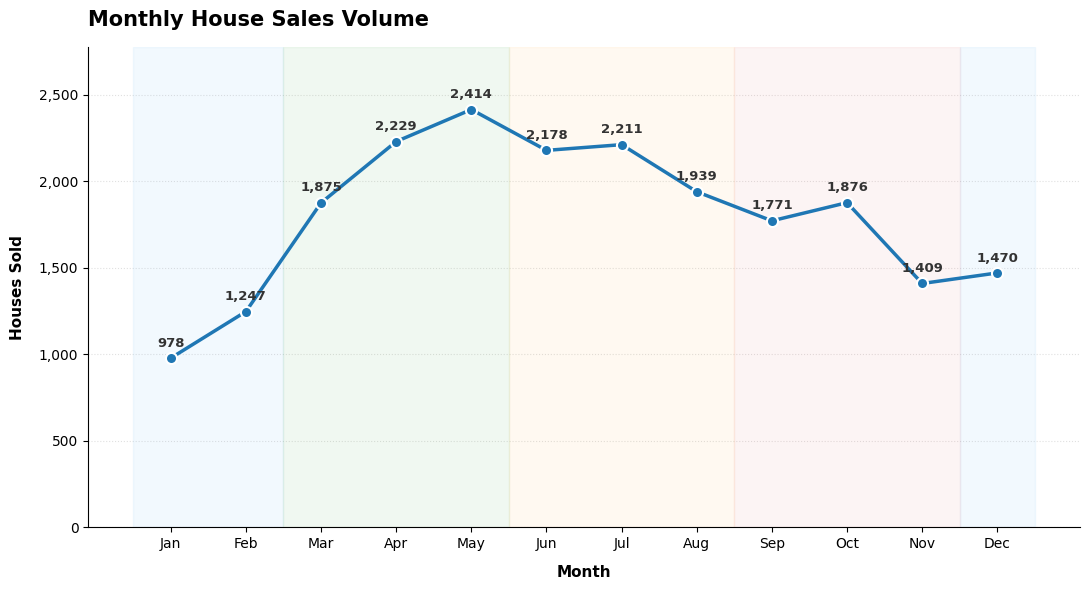

In [8]:
# Plotting monthly sales volume
fig, ax = plt.subplots(figsize=(11, 6))

# Data preparation
months_abbr = [
    'Jan',
    'Feb',
    'Mar',
    'Apr',
    'May',
    'Jun',
    'Jul',
    'Aug',
    'Sep',
    'Oct',
    'Nov',
    'Dec',
]
sales_counts = df.groupby(df['date'].dt.month).size()

# 1. Plot main line and markers
sns.lineplot(
    x=months_abbr,
    y=sales_counts,
    marker='o',
    markersize=8,
    markerfacecolor='#1f77b4',
    markeredgecolor='white',
    markeredgewidth=1.5,
    color='#1f77b4',
    linewidth=2.5,
    ax=ax,
)

# 2. Add subtle seasonal background bands
# Winter: Dec(11)-Feb(1), Spring: Mar(2)-May(4), Summer: Jun(5)-Aug(7), Fall: Sep(8)-Nov(10)
ax.axvspan(-0.5, 1.5, color='#64b5f6', alpha=0.08)  # Jan-Feb
ax.axvspan(1.5, 4.5, color='#4caf50', alpha=0.08)  # Mar-May
ax.axvspan(4.5, 7.5, color='#ffb74d', alpha=0.08)  # Jun-Aug
ax.axvspan(7.5, 10.5, color='#e57373', alpha=0.08)  # Sep-Nov
ax.axvspan(10.5, 11.5, color='#64b5f6', alpha=0.08)  # Dec

# 3. Add direct data point annotations
for x, y in zip(range(len(months_abbr)), sales_counts):
    ax.annotate(
        f'{int(y):,}',
        (x, y),
        ha='center',
        va='bottom',
        xytext=(0, 6),
        textcoords='offset points',
        fontsize=9.5,
        fontweight='bold',
        color='#333333',
    )

# 4. Polish Axes, Formatting & Spines
ax.yaxis.grid(True, linestyle=':', alpha=0.6, color='#cccccc')
ax.set_axisbelow(True)
sns.despine(top=True, right=True)

# Y-axis scaling with padding so annotations aren't cut off
ax.set_ylim(bottom=0, top=max(sales_counts) * 1.15)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Typography
plt.title(
    'Monthly House Sales Volume',
    fontsize=15,
    fontweight='bold',
    pad=15,
    loc='left',
)
plt.xlabel('Month', fontsize=11, labelpad=10, fontweight='bold')
plt.ylabel('Houses Sold', fontsize=11, labelpad=10, fontweight='bold')

plt.tight_layout()
plt.show()

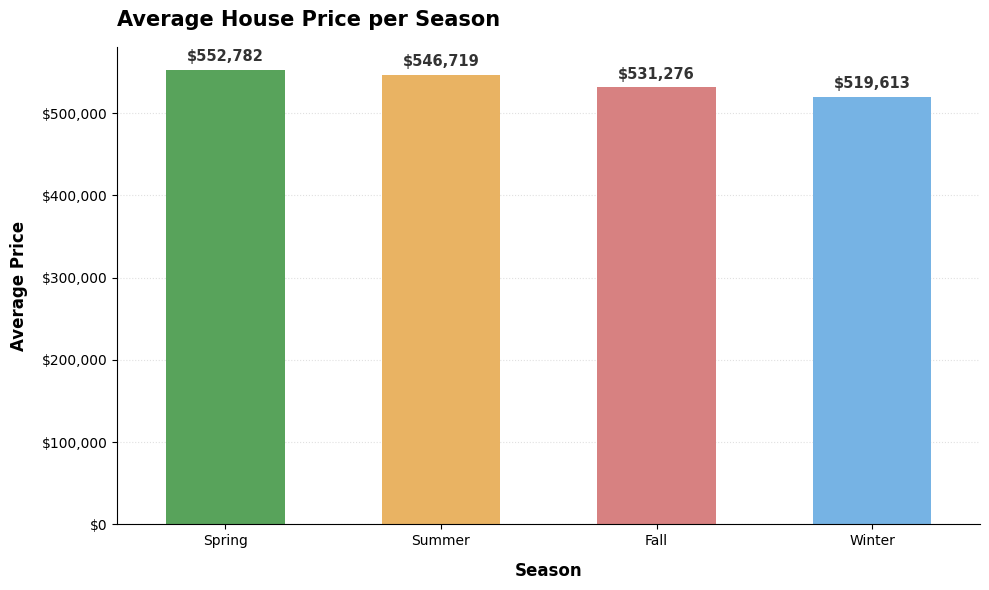

In [9]:
# Plotting Average House Price per Season
fig, ax = plt.subplots(figsize=(10, 6))

# Define a clean, modern color palette
season_order = ['Spring','Summer','Fall','Winter']

# Plot bars
bars = sns.barplot(
    data=df,
    x="season",
    y="price",
    order=season_order,
    palette=season_palette,
    errorbar=None,
    ax=ax,
    width=0.55,  # Slightly narrower bars look more modern
)

# Add value labels on top of each bar
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        f"${int(height):,}",
        (bar.get_x() + bar.get_width() / 2.0, height),
        ha="center",
        va="bottom",
        xytext=(0, 4),
        textcoords="offset points",
        fontsize=10.5,
        fontweight="bold",
        color="#333333",
    )


# 6. Polish Axes & Gridlines
ax.yaxis.grid(True, linestyle=":", alpha=0.6, color="#cccccc")
ax.set_axisbelow(True)  # Gridlines sit behind bars
sns.despine(top=True, right=True)  # Remove top & right borders

# Set y-axis limits with padding so top labels are not clipped
ax.set_ylim(bottom = 0)

# Formatting Labels & Titles
plt.title(
    "Average House Price per Season",
    fontsize=15,
    fontweight="bold",
    pad=15,
    loc="left",
)
plt.xlabel("Season", fontsize=12, labelpad=10, fontweight="bold")
plt.ylabel("Average Price", fontsize=12, labelpad=10, fontweight="bold")

ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"${int(x):,}")
)

plt.tight_layout()
plt.show()

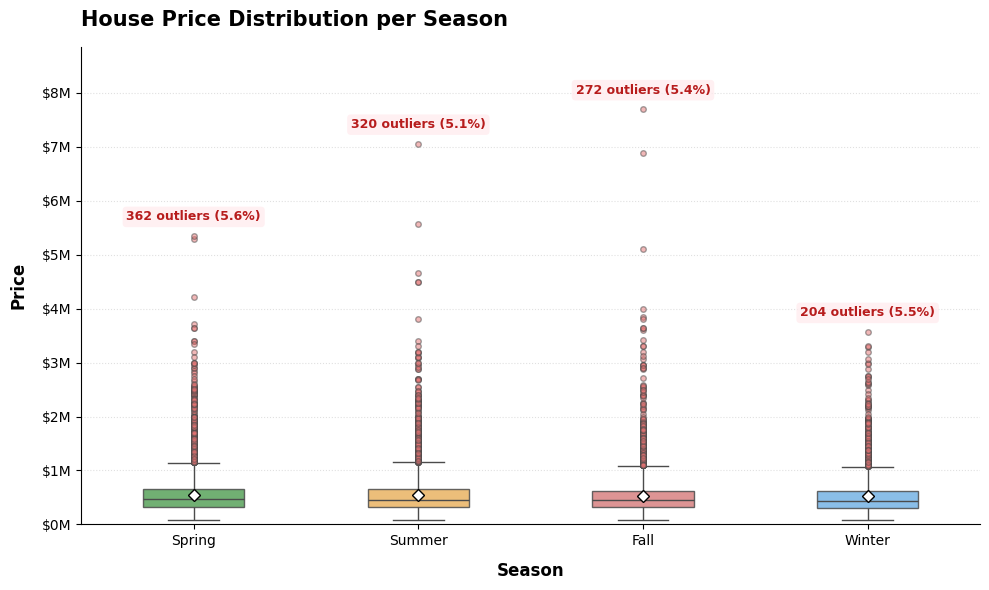

In [10]:
# Plotting distribution of house prices per season
fig, ax = plt.subplots(figsize=(10, 6))

df_plot = df.assign(price_m=df['price'] / 1e6)

# Season color mapping
season_palette = {
    'Spring': '#4caf50',
    'Summer': '#ffb74d',
    'Fall': '#e57373',
    'Winter': '#64b5f6',
}

# 1. Boxplot with custom mean and outlier styling
sns.boxplot(
    data=df_plot,
    x='season',
    y='price_m',
    order=season_order,
    palette=season_palette,
    showmeans=True,
    meanprops={
        "marker": "D",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": "6",
    },
    flierprops={
        "marker": "o",
        "markersize": 4,
        "markerfacecolor": "#e57373",
        "alpha": 0.5,
    },
    boxprops={"alpha": 0.85},
    width=0.45,
    ax=ax,
)

# 2. Outlier calculation (Count + Percentage) & Annotation placement
for i, season in enumerate(season_order):
    season_data = df_plot[df_plot['season'] == season]['price_m'].dropna()
    total_count = len(season_data)

    q1 = season_data.quantile(0.25)
    q3 = season_data.quantile(0.75)
    iqr = q3 - q1

    upper_bound = q3 + 1.5 * iqr
    lower_bound = q1 - 1.5 * iqr

    outliers = season_data[
        (season_data > upper_bound) | (season_data < lower_bound)
    ]
    n_outliers = len(outliers)
    
    # Calculate percentage
    pct_outliers = (n_outliers / total_count) * 100 if total_count > 0 else 0

    # Annotate with count and percentage
    max_val = season_data.max()
    ax.text(
        x=i,
        y=max_val + (df_plot['price_m'].max() * 0.03),
        s=f'{n_outliers} outliers ({pct_outliers:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        color='#b71c1c',
        bbox=dict(
            boxstyle='round,pad=0.3',
            facecolor='#ffebee',
            edgecolor='none',
            alpha=0.75,
        ),
    )

# 3. Polish Axes & Formatting
ax.yaxis.grid(True, linestyle=':', alpha=0.6, color='#cccccc')
ax.set_axisbelow(True)
sns.despine(top=True, right=True)

ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'${x:.1f}M'.replace('.0M', 'M'))
)

ax.set_ylim(bottom=0, top=df_plot['price_m'].max() * 1.15)

plt.title(
    'House Price Distribution per Season',
    fontsize=15,
    fontweight='bold',
    pad=15,
    loc='left',
)
plt.xlabel('Season', fontsize=12, labelpad=10, fontweight='bold')
plt.ylabel('Price', fontsize=12, labelpad=10, fontweight='bold')

plt.tight_layout()
plt.show()


Every season has a similar share of high-end outliers (~5–6%), just to be sure we compare prices with both the median and an outlier-cleaned dataset. 


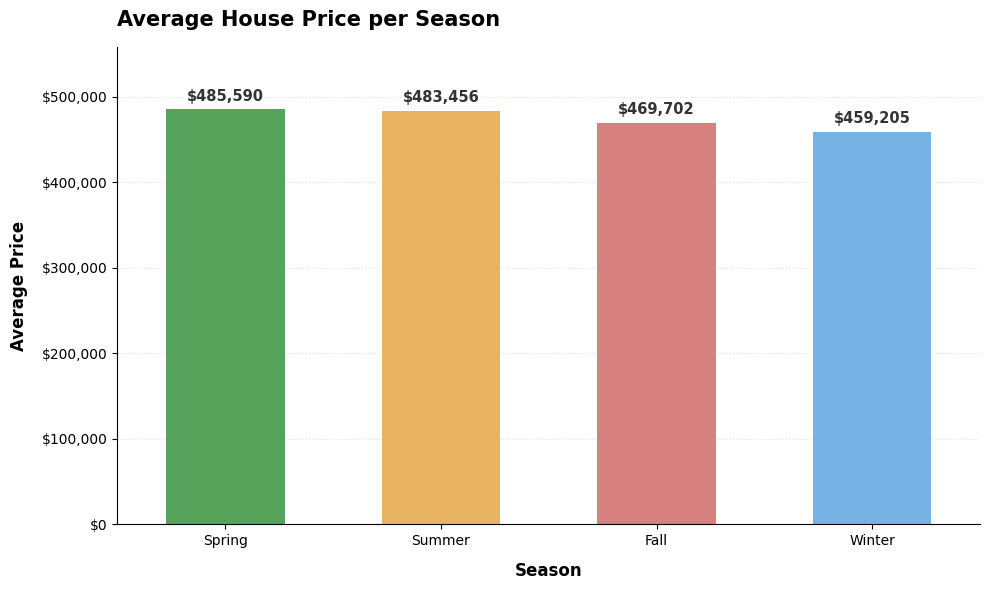

In [11]:
# Plotting house prices without outliers
fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars
bars = sns.barplot(
    data=df_clean,
    x="season",
    y="price",
    order=season_order,
    palette=season_palette,
    errorbar=None,
    ax=ax,
    width=0.55,  # Slightly narrower bars look more modern
)

# 1. Calculate seasonal means
seasonal_means = df_clean.groupby("season")["price"].mean()
spring_price = seasonal_means["Spring"]
winter_price = seasonal_means["Winter"]
diff = spring_price - winter_price

# 2. Add value labels on top of each bar
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        f"${int(height):,}",
        (bar.get_x() + bar.get_width() / 2.0, height),
        ha="center",
        va="bottom",
        xytext=(0, 4),
        textcoords="offset points",
        fontsize=10.5,
        fontweight="bold",
        color="#333333",
    )


# 6. Polish Axes & Gridlines
ax.yaxis.grid(True, linestyle=":", alpha=0.6, color="#cccccc")
ax.set_axisbelow(True)  # Gridlines sit behind bars
sns.despine(top=True, right=True)  # Remove top & right borders

# Set y-axis limits with padding so top labels are not clipped
ax.set_ylim(0, max(seasonal_means) * 1.15)

# Formatting Labels & Titles
plt.title(
    "Average House Price per Season",
    fontsize=15,
    fontweight="bold",
    pad=15,
    loc="left",
)
plt.xlabel("Season", fontsize=12, labelpad=10, fontweight="bold")
plt.ylabel("Average Price", fontsize=12, labelpad=10, fontweight="bold")

ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"${int(x):,}")
)

plt.tight_layout()
plt.show()

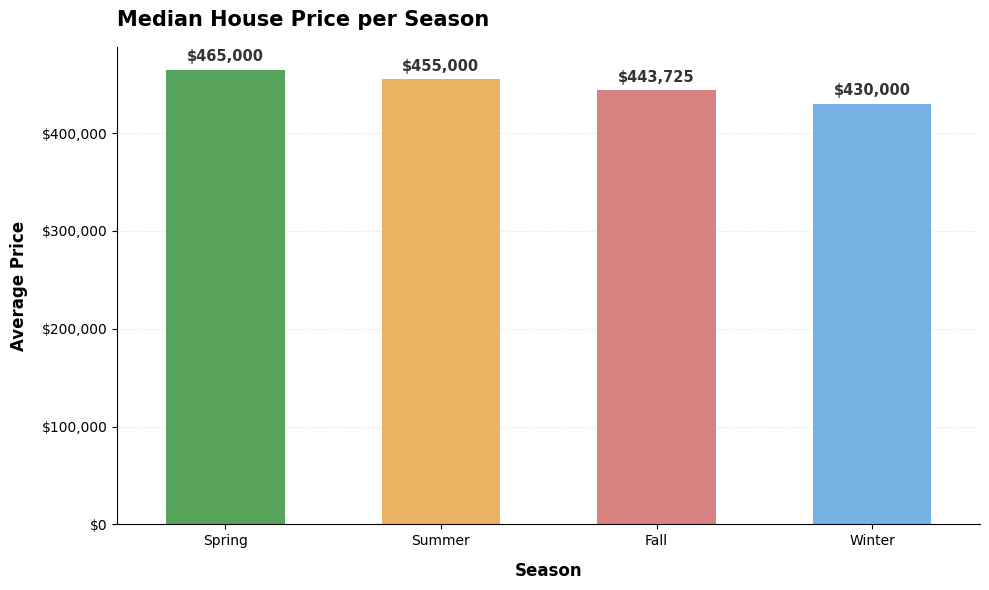

In [12]:
## Plotting median house prices per season

fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars
bars = sns.barplot(
    data=df,
    x="season",
    y="price",
    order=season_order,
    estimator='median',
    palette=season_palette,
    errorbar=None,
    ax=ax,
    width=0.55,  # Slightly narrower bars look more modern
)
# Add value labels on top of each bar
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        f"${int(height):,}",
        (bar.get_x() + bar.get_width() / 2.0, height),
        ha="center",
        va="bottom",
        xytext=(0, 4),
        textcoords="offset points",
        fontsize=10.5,
        fontweight="bold",
        color="#333333",
    )
# Polish Axes & Gridlines
ax.yaxis.grid(True, linestyle=":", alpha=0.6, color="#cccccc")
ax.set_axisbelow(True)  # Gridlines sit behind bars
sns.despine(top=True, right=True)  # Remove top & right borders

# Set y-axis limits with padding so top labels are not clipped
ax.set_ylim(bottom = 0)

# Formatting Labels & Titles
plt.title(
    "Median House Price per Season",
    fontsize=15,
    fontweight="bold",
    pad=15,
    loc="left",
)
plt.xlabel("Season", fontsize=12, labelpad=10, fontweight="bold")
plt.ylabel("Average Price", fontsize=12, labelpad=10, fontweight="bold")

ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"${int(x):,}")
)

plt.tight_layout()
plt.show()

Trends remain the same!

**H1 — Verdict: partially confirmed.** 

Prices are **highest in Spring** (not Summer as hypothesized) and **lowest in Winter** —
about a 6% gap between the two. Sales *volume* follows an even sharper seasonal pattern,
peaking in May (2,414 sales) and bottoming out in January (978 sales). For a seller-investor,
this points to **buying in Winter and selling in Spring** to capture the widest spread.



## 3. Hypothesis 2 — Location & Return on Investment

> *Homes located closer to Seattle allow for a higher return on investment.*

Using the repeat-sales dataset built in Section 1 (`df_resales`, 177 properties sold more
than once), we first test a simple linear relationship between distance-to-Seattle and
annualized ROI, then zoom into geographic clusters to see if a spatial pattern
exists instead.


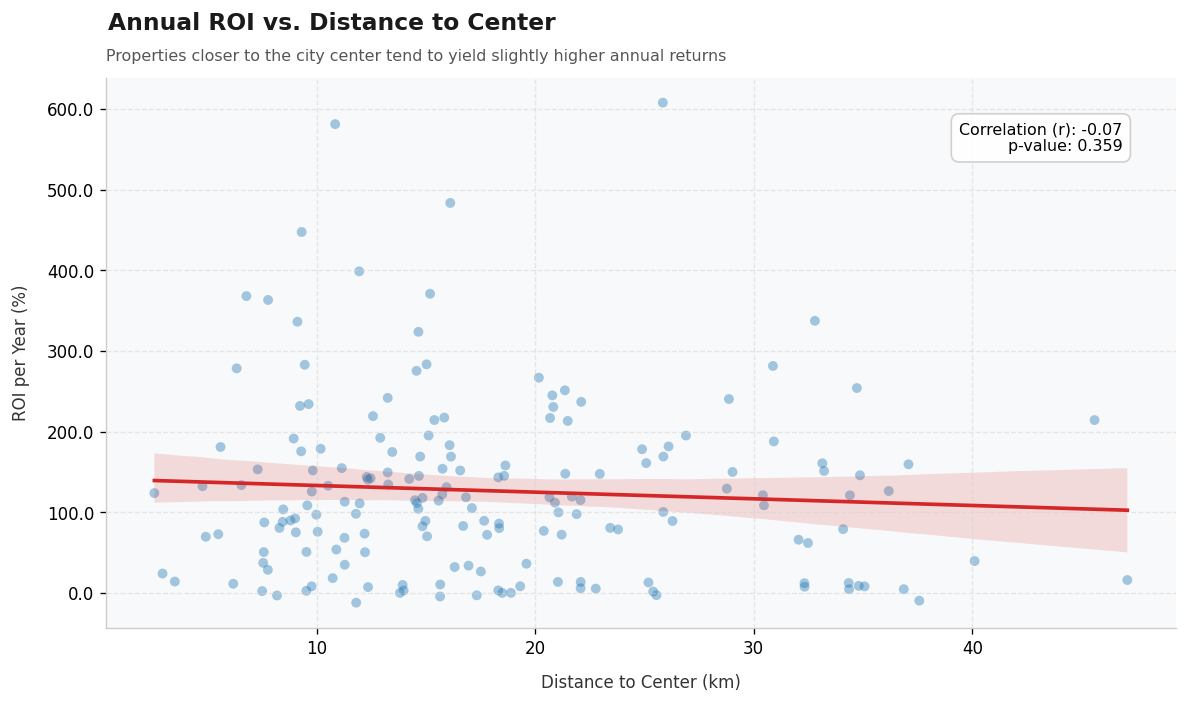

In [13]:
# Scatterplot and correlation of distance to Seattle and ROI
from scipy import stats

# 1. Calculate Pearson correlation coefficient & p-value
valid_data = df_resales.dropna(subset=['distance', 'pyear_increase'])
r, p_val = stats.pearsonr(valid_data['distance'], valid_data['pyear_increase'])

# 2. Set up high-DPI figure with modern aesthetic
fig, ax = plt.subplots(figsize=(10, 6), dpi=120)
ax.set_facecolor("#f8f9fa")
fig.patch.set_facecolor("#ffffff")

# 3. Plot Scatter + Regression Line
sns.regplot(
    data=valid_data,
    x="distance",
    y="pyear_increase",
    scatter_kws={
        "alpha": 0.4,
        "s": 35,
        "color": "#1f77b4",
        "edgecolor": "none",
    },
    line_kws={"color": "#d62728", "linewidth": 2.2},  # Red trendline
    ax=ax,
)

# 4. Add Custom Annotation Box for Correlation Stats
annot_text = f"Correlation (r): {r:.2f}\np-value: {p_val:.3f}"
ax.text(
    0.95,
    0.92,
    annot_text,
    transform=ax.transAxes,
    fontsize=9.5,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="#cccccc",
        alpha=0.9,
    ),
)

# 5. Clean Axis Spines & Grid
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#cccccc")
ax.grid(True, linestyle="--", alpha=0.5, color="#d3d3d3")

# 1. Position suptitle higher up (y=0.98)
plt.suptitle(
    "Annual ROI vs. Distance to Center",
    fontsize=14,
    fontweight="bold",
    x=0.095,
    y=0.97,
    ha="left",
    color="#1a1a1a",
)

# 2. Position the subtitle lower with smaller padding
plt.title(
    "Properties closer to the city center tend to yield slightly higher annual returns",
    fontsize=9.5,
    color="#555555",
    pad=10,
    loc="left",
)

# 3. Reserve top 10% space in tight_layout so suptitle isn't squished
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.xlabel("Distance to Center (km)", fontsize=10, labelpad=10, color="#333333")
plt.ylabel("ROI per Year (%)", fontsize=10, labelpad=10, color="#333333")

# Set percentage formatting on y-axis
ax.yaxis.set_major_formatter("{x:.1f}")

plt.tight_layout()
plt.show()


The correlation is **essentially flat and not statistically significant**
(r = -0.07, p = 0.359) — simple distance-to-Seattle does **not** reliably predict ROI.
Before concluding location doesn't matter, we check whether returns instead cluster
around *specific* neighborhoods, using the 6×6 geographic grid built earlier.


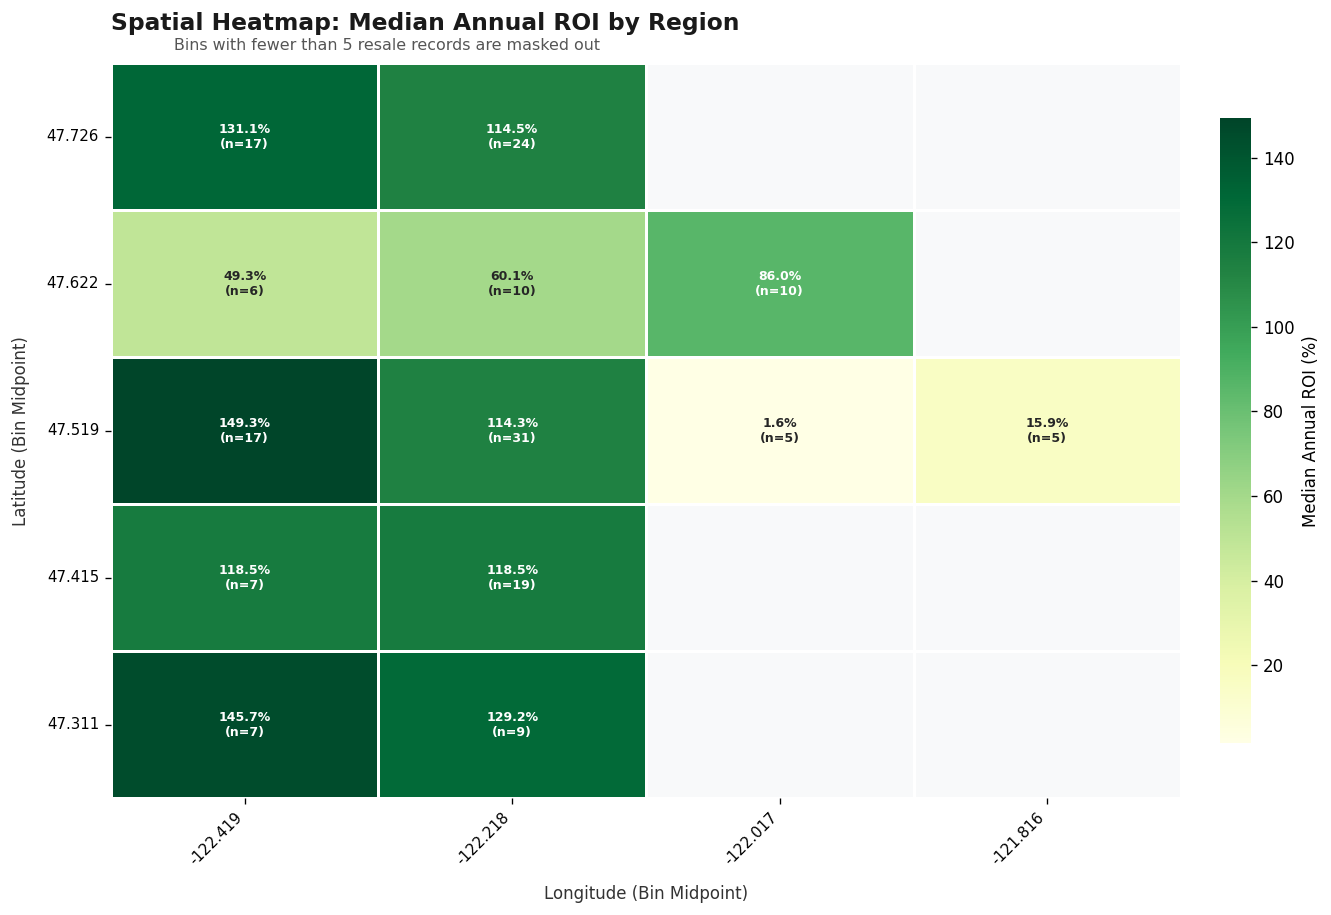

In [14]:
# Heatmap of ROI per year
heatmap_data = df_resales.pivot_table(
    index='lat_bin', columns='long_bin', values='pyear_increase', aggfunc='median'
).sort_index(ascending=False)

counts = df_resales.pivot_table(
    index='lat_bin', columns='long_bin', values='pyear_increase', aggfunc='count'
).sort_index(ascending=False)

# Mask cells with fewer than 5 records
heatmap_data_filtered = heatmap_data.where(counts >= 5)

# 2. Drop completely empty outer rows/cols to zoom in on data
valid_rows = heatmap_data_filtered.dropna(how='all', axis=0).index
valid_cols = heatmap_data_filtered.dropna(how='all', axis=1).columns

heatmap_data_filtered = heatmap_data_filtered.loc[valid_rows, valid_cols]
counts_filtered = counts.loc[valid_rows, valid_cols]

# 3. Format index and columns using bin midpoints
heatmap_data_filtered.index = [f'{i.mid:.3f}' for i in heatmap_data_filtered.index]
heatmap_data_filtered.columns = [f'{c.mid:.3f}' for c in heatmap_data_filtered.columns]

# 4. Create custom string matrix with both ROI and Count (n)
annot_matrix = pd.DataFrame(
    index=heatmap_data_filtered.index,
    columns=heatmap_data_filtered.columns
)

for r in range(heatmap_data_filtered.shape[0]):
    for c in range(heatmap_data_filtered.shape[1]):
        val = heatmap_data_filtered.iloc[r, c]
        n_count = counts_filtered.iloc[r, c]
        
        if pd.notna(val):
            # Display ROI % on line 1, sample count (n=...) on line 2
            annot_matrix.iloc[r, c] = f'{val:.1f}%\n(n={int(n_count)})'
        else:
            annot_matrix.iloc[r, c] = ''

# 5. Set up Matplotlib figure
fig, ax = plt.subplots(figsize=(12, 8), dpi=120)
ax.set_facecolor('#f8f9fa')

# 6. Plot Heatmap
sns.heatmap(
    heatmap_data_filtered,
    cmap='YlGn',
    annot=annot_matrix,
    fmt='',  # Keep raw text strings
    linewidths=0.8,
    linecolor='white',
    cbar_kws={
        'label': 'Median Annual ROI (%)',
        'shrink': 0.85,
        'pad': 0.03,
    },
    annot_kws={'size': 7.5, 'weight': 'bold'},  # Slightly smaller font to fit both lines
    ax=ax,
)

# 7. Polish Typography & Spacing
plt.title(
    'Spatial Heatmap: Median Annual ROI by Region',
    fontsize=14,
    fontweight='bold',
    pad=20,
    loc='left',
    color='#1a1a1a',
)

plt.suptitle(
    'Bins with fewer than 5 resale records are masked out',
    fontsize=9.5,
    color='#555555',
    x=0.125,
    y=0.92,
    ha='left',
)

plt.xlabel('Longitude (Bin Midpoint)', fontsize=10, labelpad=10, color='#333333')
plt.ylabel('Latitude (Bin Midpoint)', fontsize=10, labelpad=10, color='#333333')

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()


**H2 — Verdict: mostly rejected, but with hints towards a geographic pattern.**

Distance to Seattle alone does not strongly predict ROI. However, the spatial heatmap shows
median annual ROI ranging from **~2% to ~150%** depending on the specific grid cell —
location clearly still matters, just not along a simple "closer is better" gradient. The
practical takeaway is to target **specific high-performing clusters**, not just proximity
to the city.



## 4. Hypothesis 3 — Renovation Value by Home Age

> *For homes renovated in the last 20 years, the price increase from renovation is
> largest for homes built before 1950.*

We restrict to properties with a recent, on-record renovation (or none at all) and compare
price-per-sqft for renovated vs. unrenovated homes, split by whether the home was built
before or after 1950.


In [19]:
# 1. Prepare Base Filtering & Create Binary Flags
df_reno = df.dropna(subset=['yr_renovated']).copy()
df_reno = df_reno[(df_reno['yr_renovated'] > 1995) | (df_reno['yr_renovated'] == 0)]

df_reno['is_renovated'] = np.where(df_reno['yr_renovated'] > 0, 1, 0)
df_reno['is_pre1950'] = np.where(df_reno['yr_built'] < 1950, 'Built Pre-1950', 'Built 1950+')
df_reno['price_per_sqft'] = df_reno['price'] / df_reno['sqft_living']

# 2. Summary Table
summary_table = df_reno.groupby(['is_pre1950', 'is_renovated'])[['price', 'price_per_sqft']].agg(['median', 'mean', 'count'])
print(summary_table)


# 3. Calculate Renovation Premiums
def get_renovation_premium(data_subset):
    unreno = data_subset[data_subset['is_renovated'] == 0]['price_per_sqft'].median()
    reno = data_subset[data_subset['is_renovated'] == 1]['price_per_sqft'].median()
    return ((reno - unreno) / unreno) * 100

pre_1950_premium = get_renovation_premium(df_reno[df_reno['yr_built'] < 1950])
post_1950_premium = get_renovation_premium(df_reno[df_reno['yr_built'] >= 1950])

print(f"Pre-1950 Renovation Premium: {pre_1950_premium:.2f}%")
print(f"Post-1950 Renovation Premium: {post_1950_premium:.2f}%")


                                 price                   price_per_sqft  \
                                median       mean  count         median   
is_pre1950     is_renovated                                               
Built 1950+    0            445000.000 532318.253  13475        228.070   
               1            717000.000 856385.254    201        301.449   
Built Pre-1950 0            458000.000 525737.778   3530        320.024   
               1            701500.000 796085.388    232        322.891   

                                            
                               mean  count  
is_pre1950     is_renovated                 
Built 1950+    0            242.929  13475  
               1            326.587    201  
Built Pre-1950 0            330.799   3530  
               1            334.742    232  
Pre-1950 Renovation Premium: 0.90%
Post-1950 Renovation Premium: 32.17%


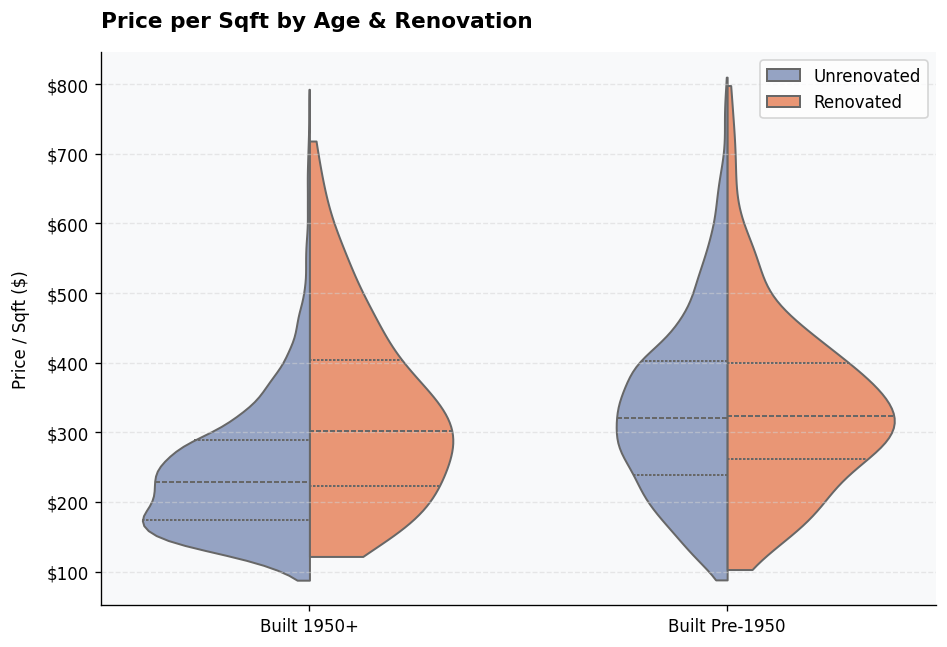

In [20]:
# Plotting Renovation status and house age
fig, ax = plt.subplots(figsize=(8, 5.5), dpi=120)
ax.set_facecolor("#f8f9fa")

# Split violin plot
sns.violinplot(
    data=df_reno,
    x='is_pre1950',
    y='price_per_sqft',
    hue='is_renovated',
    split=True,
    inner="quart",
    palette=['#8da0cb', '#fc8d62'],
    cut=0,
    linewidth=1.2,
    ax=ax
)

# Custom Legend
handles, _ = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=['Unrenovated', 'Renovated'],
    title=None,
    frameon=True,
    facecolor='white',
    loc='upper right'
)

# Minimal Spines & Grid
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.5, axis='y', color='#d3d3d3')

# Clean Title & Axis Labels
ax.set_title("Price per Sqft by Age & Renovation", fontsize=13, fontweight='bold', pad=15, loc='left')
ax.set_xlabel("")  # Removed redundant label
ax.set_ylabel("Price / Sqft ($)", fontsize=10, labelpad=10)

# Format y-axis as currency
ax.yaxis.set_major_formatter("${x:,.0f}")

plt.tight_layout()
plt.show()


**H3 — Verdict: rejected (and reversed).** 

The data shows the **opposite** of the hypothesis. Renovating a home built **1950 or
later** lifts price/sqft by **+32.17%**, while renovating a home built **before 1950**
adds only **+0.90%**.


## 5. Summary: Key Insights & Recommendations for Charles Christensen

| # | Insight | Recommendation |
|---|---------|-----------------|
| 1 | **Timing:** Spring prices (avg. $552,782) run ~6% above Winter (avg. $519,613); sales volume peaks in May (2,414) and troughs in January (978). | **Buy in Winter, sell in Spring** to capture the widest price spread and strongest buyer demand. |
| 2 | **Renovation:** Homes built 1950+ see a **+32.17%** price/sqft lift from renovation, vs. only **+0.90%** for homes built before 1950. | **Prioritize renovation spend on post-1950 properties** — pre-1950 homes retain value from character/location already, so renovation there has little payoff. |
| 3 | **Location (geographic):** Distance to Seattle alone doesn't predict ROI (r = -0.07, not significant), but ROI by grid cluster ranges from ~2% to ~150%. | **Target specific high-ROI micro-neighborhoods** identified via clustering, rather than assuming "closer to the city" is automatically better. |
